# Movie Recommendation System – Data Collection & Preprocessing

This notebook covers the data collection, understanding, cleaning, integration, and transformation steps for the movie recommendation project.

## 1. Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Datasets

The project uses MovieLens for user interactions and TMDb for movie metadata and descriptions.

In [43]:
ratings = pd.read_csv('../data/raw/ratings.csv')
movies = pd.read_csv('../data/raw/movies.csv')
tmdb = pd.read_csv('../data/raw/tmdb_5000_movies.csv')

## 3. Data Understanding

 we inspect the datasets, their structure, and missing values.

In [44]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [45]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [46]:
tmdb.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [47]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [48]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [49]:
tmdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [50]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [51]:
tmdb.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

## 4. Basic Dataset Statistics

These statistics summarize the size of the datasets and the scale of the recommendation problem.

In [52]:
num_users = ratings['userId'].nunique()
num_movies = movies['movieId'].nunique()
num_ratings = len(ratings)

summary_stats = pd.DataFrame({
    'Metric': ['Number of users', 'Number of movies', 'Number of ratings'],
    'Value': [num_users, num_movies, num_ratings]
})
summary_stats

,Metric,Value
0,Number of users,610
1,Number of movies,9742
2,Number of ratings,100836


## 5. Merge MovieLens Ratings with Movie Metadata

We combine user ratings with movie titles and genres using `movieId`.

In [53]:
df = pd.merge(ratings, movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


## 6. Data Cleaning

We remove duplicates and standardize movie titles to improve consistency before integration.

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df['title'] = df['title'].str.strip().str.lower()

In [58]:
tmdb['title'] = tmdb['title'].str.strip().str.lower()

## 7. Prepare TMDb Metadata

We keep only the most useful fields for metadata enrichment and NLP, then handle missing values.

In [59]:
tmdb_clean = tmdb[['title', 'overview', 'genres', 'popularity', 'vote_average', 'runtime', 'release_date']].copy()

In [60]:
tmdb_clean['overview'] = tmdb_clean['overview'].fillna('No description available')

In [61]:
tmdb_clean['runtime'] = tmdb_clean['runtime'].fillna(tmdb_clean['runtime'].median())

In [62]:
tmdb_clean['release_date'] = tmdb_clean['release_date'].fillna('Unknown')

In [63]:
tmdb_clean.isnull().sum()

title           0
overview        0
genres          0
popularity      0
vote_average    0
runtime         0
release_date    0
dtype: int64

## 8. Integrate MovieLens with TMDb

We merge the cleaned MovieLens data with TMDb movie metadata using the movie title. Note that exact title matching may not be perfect for all movies.

In [68]:
df['title_clean'] = df['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()
tmdb_clean['title_clean'] = tmdb_clean['title'].str.strip()

In [69]:
merged_movies = pd.merge(df, tmdb_clean, on='title_clean', how='left')

In [70]:
merged_movies['overview'].notnull().sum()

np.int64(52440)

In [71]:
merged_movies['overview'].isnull().sum()

np.int64(48590)

Not all movie titles could be matched exactly between MovieLens and TMDb, so some metadata fields remain missing after merging.

## 9. Data Transformation

We transform the user history into transaction format for pattern mining and edge-list format for graph analysis.

In [72]:
transactions = df.groupby('userId')['title'].apply(list).reset_index()
transactions.head()

,userId,title
0,1,"[toy story (1995), grumpier old men (1995), he..."
1,2,"[shawshank redemption, the (1994), tommy boy (..."
2,3,"[dangerous minds (1995), schindler's list (199..."
3,4,"[get shorty (1995), twelve monkeys (a.k.a. 12 ..."
4,5,"[toy story (1995), get shorty (1995), babe (19..."


In [73]:
type(transactions['title'][0])

list

In [74]:
# Creating edge list for graph analysis (user -> movie)
edges = df[['userId', 'movieId']].copy()
edges.head()

,userId,movieId
0,1,1
1,1,3
2,1,6
3,1,47
4,1,50


## 10. Additional Insights

We compute the average number of watched movies per user.

In [75]:
transactions['movie_count'] = transactions['title'].apply(len)
transactions['movie_count'].mean()

np.float64(165.30491803278687)

## 11. Visualizations

These plots provide a quick understanding of rating patterns and viewing activity per user.

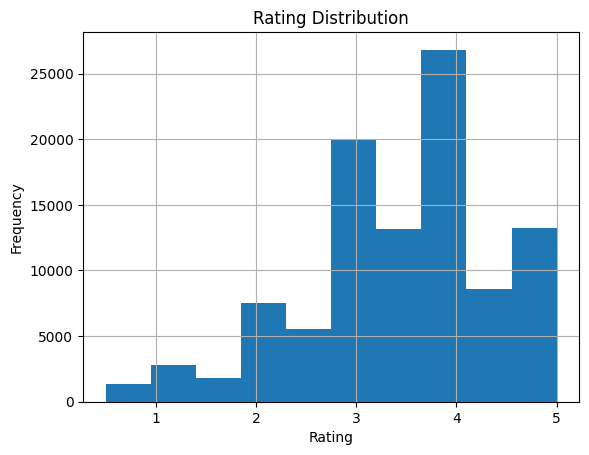

In [76]:
ratings['rating'].hist()
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

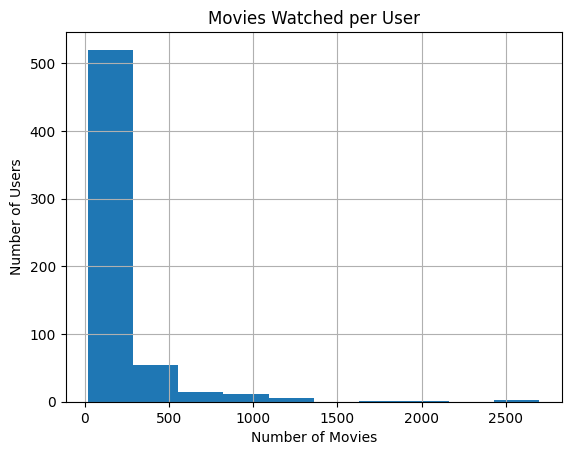

In [77]:
transactions['movie_count'].hist()
plt.title('Movies Watched per User')
plt.xlabel('Number of Movies')
plt.ylabel('Number of Users')
plt.show()

## 12. Save Processed Files

Finally, we save all generated datasets for later use in pattern mining, graph analysis, and NLP tasks.

In [78]:
cleaned_dataset = merged_movies.copy()
cleaned_dataset.to_csv('../data/processed/cleaned_dataset.csv', index=False)

In [79]:
transactions_to_save = transactions[['userId', 'title']]
transactions_to_save.to_csv('../data/processed/transactions.csv', index=False)

In [80]:
edges.to_csv('../data/processed/edges.csv', index=False)

In [81]:
tmdb_clean.to_csv('../data/processed/tmdb_cleaned.csv', index=False)

In [82]:
merged_movies.to_csv('../data/processed/merged_movies_dataset.csv', index=False)

## 13. Summary

- Collected MovieLens and TMDb datasets
- Inspected dataset structure and missing values
- Cleaned and standardized movie titles
- Integrated user interactions with movie metadata
- Created transaction and edge-list datasets
- Saved the processed outputs for downstream analysis